In [427]:
import kagglehub
path = kagglehub.dataset_download("uciml/student-alcohol-consumption")

Using Colab cache for faster access to the 'student-alcohol-consumption' dataset.


In [428]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [429]:
df=pd.read_csv(path+"/student-mat.csv")

In [430]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [431]:
df.shape

(395, 33)

In [432]:
df.corr(numeric_only=True)["G3"].sort_values(ascending=False)

,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


In [433]:
df=df.drop(['school',"address","famsize","Pstatus","Mjob","Fjob","guardian","reason","Dalc","Walc"],axis=1)

In [434]:
df.shape

(395, 23)

In [435]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sex         395 non-null    object
 1   age         395 non-null    int64 
 2   Medu        395 non-null    int64 
 3   Fedu        395 non-null    int64 
 4   traveltime  395 non-null    int64 
 5   studytime   395 non-null    int64 
 6   failures    395 non-null    int64 
 7   schoolsup   395 non-null    object
 8   famsup      395 non-null    object
 9   paid        395 non-null    object
 10  activities  395 non-null    object
 11  nursery     395 non-null    object
 12  higher      395 non-null    object
 13  internet    395 non-null    object
 14  romantic    395 non-null    object
 15  famrel      395 non-null    int64 
 16  freetime    395 non-null    int64 
 17  goout       395 non-null    int64 
 18  health      395 non-null    int64 
 19  absences    395 non-null    int64 
 20  G1        

In [436]:
df=df.drop_duplicates()

In [437]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [438]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
for col in df.select_dtypes(exclude=np.number).columns:
  df[col]=le.fit_transform(df[col])

In [439]:
df.head()

,sex,age,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,0,18,4,4,2,2,0,1,0,0,0,1,1,0,0,4,3,4,3,6,5,6,6
1,0,17,1,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,3,4,5,5,6
2,0,15,1,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,3,10,7,8,10
3,0,15,4,2,1,3,0,0,1,1,1,1,1,1,1,3,2,2,5,2,15,14,15
4,0,16,3,3,1,2,0,0,1,1,0,1,1,0,0,4,3,2,5,4,6,10,10


In [440]:
df.shape

(395, 23)

In [441]:
from sklearn.model_selection import train_test_split

In [442]:
X=df.iloc[:, :-1] #all rows,all cols (-1->except last one)

In [443]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [444]:
X

array([[-0.94817639,  1.02304645,  1.14385567, ...,  0.03642446,
        -1.78246688, -1.25479105],
       [-0.94817639,  0.23837976, -1.60000865, ..., -0.21379577,
        -1.78246688, -1.52097927],
       [-0.94817639, -1.33095364, -1.60000865, ...,  0.53686493,
        -1.1791469 , -0.72241461],
       ...,
       [ 1.05465609,  3.37704655, -1.60000865, ..., -0.33890588,
        -0.27416693, -0.72241461],
       [ 1.05465609,  1.02304645,  0.22923423, ..., -0.71423623,
         0.02749306,  0.34233827],
       [ 1.05465609,  1.80771315, -1.60000865, ..., -0.08868565,
        -0.87748691, -0.45622639]])

In [445]:
Y=df.iloc[:,-1] #all row and only last column/


In [446]:
Y

,G3
0,6
1,6
2,10
3,15
4,10
...,...
390,9
391,16
392,7
393,10


In [447]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [448]:
from sklearn.linear_model import LinearRegression

In [449]:
LR_model=LinearRegression()
LR_model.fit(X_train,Y_train)

LinearRegression()

In [450]:
LR_model.predict(X_test)  #predicted result on hidden(Test data)

array([ 6.30694445, 11.47918534,  3.0695561 ,  8.30924117,  8.89018407,
       12.70869101, 18.79258618,  7.49123944,  7.07217182, 12.72772379,
       14.8635595 ,  5.28400703, 13.76109242, 11.85895392, 14.69739208,
        8.61950301,  6.52666428, 11.39654538, 14.81707515,  7.98686134,
       14.37934566, 16.45928791, 14.96103912,  5.59067541,  8.16864153,
       20.15058172, 10.60701689,  9.17407411, 16.51763079, 10.75706441,
        9.46718133,  7.19763516, 15.05138975, 12.37319091,  5.76521772,
        5.2390467 , -2.33061912, 14.82425145, 12.35713855,  7.25777239,
        5.64982586, 10.4001056 , 14.15288447,  7.41076432, 16.74939699,
        9.86241514, 11.76633383, 13.938563  , 11.57194961, 16.20843686,
       13.99072321, 14.58411156, 11.13812754,  7.5437368 ,  3.39319426,
       12.45292583, 10.53848785,  7.05590645, 14.76468829, 16.20603885,
       12.76558173,  8.13925819,  7.76738131,  3.88699393,  4.21952675,
       16.90602552,  7.86723786,  9.31558473,  8.76015993, 15.77

In [451]:
Y_test  #actual result

,G3
78,10
371,12
248,5
55,10
390,9
...,...
367,0
210,8
75,10
104,18


In [452]:
from sklearn.metrics import accuracy_score ,confusion_matrix

In [453]:
accuracy_score=LR_model.score(X_test,Y_test)

In [454]:
print("Accuracy Score of LR Model :",accuracy_score)

Accuracy Score of LR Model : 0.8020148510450602


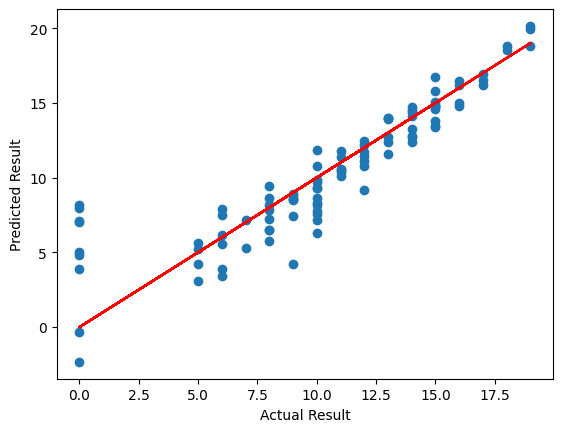

In [455]:
plt.scatter(Y_test,LR_model.predict(X_test))
plt.plot(Y_test,Y_test,color="red")
plt.xlabel('Actual Result'),
plt.ylabel("Predicted Result")
plt.show()


In [456]:
from sklearn.ensemble import RandomForestRegressor
RF_model=RandomForestRegressor()
RF_model.fit(X_train,Y_train)

RandomForestRegressor()

In [457]:
RF_model.predict(X_test)

array([ 8.65, 11.67,  6.82,  9.62,  9.23, 13.1 , 18.66,  7.01,  6.68,
       13.04, 15.61,  7.37, 14.11, 11.57, 14.  ,  8.27,  2.55, 10.51,
       15.32,  3.94, 13.96, 15.88, 15.07,  6.76,  7.96, 18.63,  9.89,
        9.  , 18.01, 10.63,  8.52,  9.05, 15.27, 13.18,  1.75,  6.41,
        0.09, 14.86, 11.97,  7.88,  6.62,  9.81, 14.13,  9.11, 14.83,
        8.77, 11.54, 14.11, 12.64, 15.51, 13.36, 15.21, 10.41,  8.83,
        6.02, 13.21, 10.71,  2.15, 15.69, 15.86, 13.33,  9.12,  8.99,
        6.26,  7.85, 18.06,  9.07, 10.01,  9.43, 15.5 ,  8.47,  9.9 ,
       13.58, 18.51, 10.23,  5.84,  9.54, 14.14,  5.7 , 13.16, 13.79,
        1.8 ,  9.06,  7.02,  8.74, 14.08,  0.14, 11.11, 15.52,  0.26,
       13.39,  9.36, 11.04,  6.05,  2.12,  8.26,  8.76, 18.25, 18.54])

In [460]:
Y_test

,G3
78,10
371,12
248,5
55,10
390,9
...,...
367,0
210,8
75,10
104,18


In [458]:
print("RF_Accuracy Score: ",RF_model.score(X_test,Y_test))

RF_Accuracy Score:  0.870428706697255


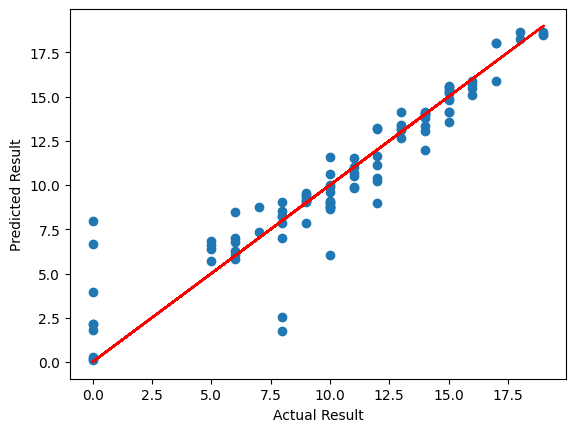

In [459]:
plt.scatter(Y_test,RF_model.predict(X_test))
plt.plot(Y_test,Y_test,color="red")
plt.xlabel('Actual Result'),
plt.ylabel("Predicted Result")
plt.show()